In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import eye, lil_matrix, diags
from joblib import Parallel, delayed
from resource_estimate_utils import *
from os.path import join
from time import time
import networkx as nx

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit import transpile
from qiskit.circuit.library import PauliEvolutionGate, RZGate
from pytket import OpType
from pytket.passes import RemoveRedundancies, CommuteThroughMultis, SequencePass, FullPeepholeOptimise, auto_rebase_pass
from pytket.extensions.qiskit import qiskit_to_tk

from qclib.gates.ldmcsu import Ldmcsu

from os.path import join
import sys
sys.path.append(join(".", ".."))
from utils import *

In [8]:
data.files

['dimensions',
 'error_tols',
 'bell_basis_1q_gate_count',
 'bell_basis_2q_gate_count',
 'one_hot_1q_gate_count',
 'one_hot_2q_gate_count']

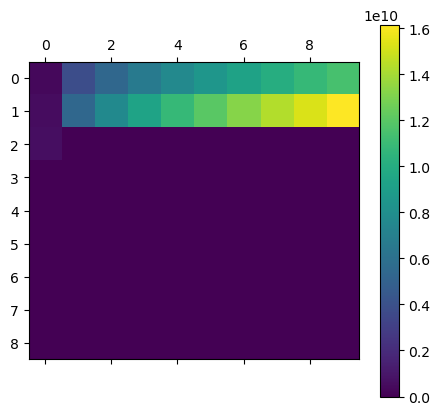

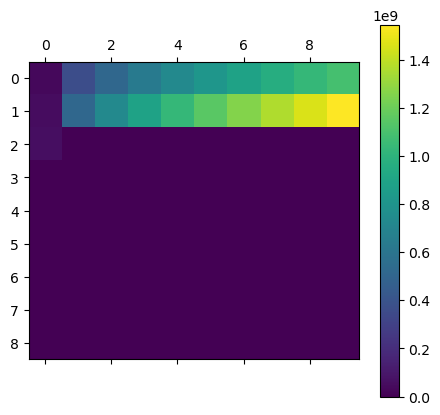

In [11]:
data = np.load("../resource_analysis_data/fig2_data.npz")
bell_basis_2q_gate_count = data["bell_basis_2q_gate_count"]
plt.matshow(bell_basis_2q_gate_count)
plt.colorbar()
plt.show()
one_hot_2q_gate_count = data["one_hot_2q_gate_count"]
plt.matshow(one_hot_2q_gate_count)
plt.colorbar()
plt.show()

In [426]:
pip freeze | grep qclib

qclib==0.1.12
Note: you may need to restart the kernel to use updated packages.


In [12]:
def estimate_one_step_trotter_error(N, N_p, R, dt, num_samples=1000, num_jobs=16):

    assert N % 2 == 0

    h = 1 / N

    H_1_diag = -eye(N) / h
    H_1_even = lil_matrix((N,N), dtype=np.complex128)
    H_1_odd = lil_matrix((N,N), dtype=np.complex128)
    H_2_even = lil_matrix((N,N), dtype=np.complex128)
    H_2_odd = lil_matrix((N,N), dtype=np.complex128)
    for i in range(N):
        if i % 2 == 0:
            H_1_even[i,(i+1)%N] = 1
            H_1_even[(i+1)%N,i] = 1
            H_2_even[i,(i+1)%N] = 1j
            H_2_even[(i+1)%N,i] = -1j
        else:
            H_1_odd[i,(i+1)%N] = 1
            H_1_odd[(i+1)%N,i] = 1
            H_2_odd[i,(i+1)%N] = 1j
            H_2_odd[(i+1)%N,i] = -1j

    H_1_even /= (2 * h)
    H_1_odd /= (2 * h)
    H_2_even /= (2 * h)
    H_2_odd /= (2 * h)

    H_F = (np.pi / R) * diags(np.fft.fftfreq(N_p, 1/N_p))

    # print(f"Estimating Trotter error w/ {num_jobs} jobs", flush=True)x
    return max(Parallel(n_jobs=num_jobs)(delayed(estimate_one_step_trotter_error_one_sample)(N, N_p, dt, H_1_diag, H_1_even, H_1_odd, H_2_even, H_2_odd, H_F) for _ in range(num_samples)))

def estimate_one_step_trotter_error_one_sample(N, N_p, dt, H_1_diag, H_1_even, H_1_odd, H_2_even, H_2_odd, H_F):

    H_1 = H_1_even + H_1_odd + H_1_diag
    H_2 = H_2_even + H_2_odd
    H_S = kron(H_1, H_F) - kron(H_2, eye(N_p))

    psi_0 = np.random.randn(N * N_p) + 1j * np.random.randn(N * N_p)
    psi_0 /= np.linalg.norm(psi_0)
    psi_no_trotter = expm_multiply(-1j * dt * (H_S), psi_0)

    psi_trotter = expm_multiply(-1j * (dt / 2) * (- kron(H_2_even, eye(N_p))), psi_0)
    psi_trotter = expm_multiply(-1j * (dt / 2) * (- kron(H_2_odd, eye(N_p))), psi_trotter)
    psi_trotter = expm_multiply(-1j * (dt / 2) * kron(H_1_even, H_F), psi_trotter)
    psi_trotter = expm_multiply(-1j * (dt / 2) * kron(H_1_odd, H_F), psi_trotter)
    psi_trotter = expm_multiply(-1j * dt * kron(H_1_diag, H_F), psi_trotter)
    psi_trotter = expm_multiply(-1j * (dt / 2) * kron(H_1_odd, H_F), psi_trotter)
    psi_trotter = expm_multiply(-1j * (dt / 2) * kron(H_1_even, H_F), psi_trotter)
    psi_trotter = expm_multiply(-1j * (dt / 2) * (- kron(H_2_odd, eye(N_p))), psi_trotter)
    psi_trotter = expm_multiply(-1j * (dt / 2) * (- kron(H_2_even, eye(N_p))), psi_trotter)

    error = np.linalg.norm(psi_no_trotter - psi_trotter)
    return error

def get_trotter_number_one_hot(N, N_p, R, T, error_tol, num_samples=1000, num_jobs=16):
    r_min, r_max = 1, 10
    while r_max * estimate_one_step_trotter_error(N, N_p, R, T / r_max, num_samples, num_jobs) > error_tol:
        r_max *= 2

    # binary search for r
    while r_max - r_min > 1:
        r = (r_min + r_max) // 2
        if r * estimate_one_step_trotter_error(N, N_p, R, T / r, num_samples, num_jobs) > error_tol:
            r_min = r
        else:
            r_max = r
    return r_max

def get_xi_pauli_op(n_p, R):
    xi_pauli_list = []
    op = n_p * ['I']
    xi_pauli_list.append((''.join(op), 1))

    for i in range(n_p - 1):
        op = n_p * ['I']
        op[n_p-1-i] = 'Z'
        xi_pauli_list.append((''.join(op), 2 ** i))
    
    op = n_p * ['I']
    op[0] = 'Z'
    xi_pauli_list.append((''.join(op), - 2 ** (n_p - 1)))

    xi_pauli_op = 0.5 * (2 * np.pi / (2 * R)) * SparsePauliOp.from_list(xi_pauli_list)
    return xi_pauli_op

def one_hot_gate_count_per_trotter_step(N, n_p, R, trotter_method="second_order"):
    '''Gets the structure for the circuit with a single Trotter step'''
    H_1_pauli_list = []
    H_2_pauli_list = []
    for j in range(N):
        # Hermitian part
        op = N * ['I']
        op[j] = 'X'
        op[(j+1)%N] = 'X'
        H_1_pauli_list.append((''.join(op), 1/2))
        op = N * ['I']
        op[j] = 'Y'
        op[(j+1)%N] = 'Y'
        H_1_pauli_list.append((''.join(op), 1/2))
        
        # Anti-Hermitian part
        op = N * ['I']
        op[j] = 'X'
        op[(j+1)%N] = 'Y'
        H_2_pauli_list.append((''.join(op), 1/2))
        op = N * ['I']
        op[j] = 'Y'
        op[(j+1)%N] = 'X'
        H_2_pauli_list.append((''.join(op), -1/2))

    xi_pauli_list = get_xi_pauli_op(n_p, R).to_list()

    pauli_list = []
    for i in range(len(H_1_pauli_list)):
        for j in range(len(xi_pauli_list)):
            pauli_list.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], -H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
    for i in range(len(H_2_pauli_list)):
        pauli_list.append((H_2_pauli_list[i][0] + ''.join(n_p * ['I']), -H_2_pauli_list[i][1]))

    pauli_op = SparsePauliOp.from_list(pauli_list)

    # Compute number of gates per Trotter step
    if trotter_method == "first_order" or trotter_method == "randomized_first_order":
        circuit = LieTrotter(reps=1).synthesize(PauliEvolutionGate(pauli_op.group_commuting()))
    elif trotter_method == "second_order":
        circuit = SuzukiTrotter(order=2, reps=1).synthesize(PauliEvolutionGate(pauli_op.group_commuting()))
    else:
        raise ValueError(f"{trotter_method} not supported")

    compiled_circuit = transpile(circuit, basis_gates=['rxx', 'rx', 'ry', 'rz'], optimization_level=3)

    tket_circuit = qiskit_to_tk(compiled_circuit)
    gateset = {OpType.Rx, OpType.Ry, OpType.Rz, OpType.XXPhase}
    rebase = auto_rebase_pass(gateset) 
    comp = SequencePass([FullPeepholeOptimise(), CommuteThroughMultis(), RemoveRedundancies(), rebase])
    comp.apply(tket_circuit)

    # Gates per Trotter step
    num_single_qubit_gates, num_two_qubit_gates = tket_circuit.n_1qb_gates(), tket_circuit.n_2qb_gates()
    print(f"1q gates: {num_single_qubit_gates}, 2q gates: {num_two_qubit_gates}")

    return num_single_qubit_gates, num_two_qubit_gates

def get_mcrz(n, theta):
    circ = QuantumCircuit(n)
    if n == 2:
        circ.crz(theta, control_qubit=0, target_qubit=1)
    else:
        su2_matrix = np.array([[np.exp(-1.j * theta / 2.), 0.], [0., np.exp(1.j * theta / 2.)]])

        circ.append(Ldmcsu(su2_matrix, int(n-1)), list(range(n)))
    return circ

# Std binary implementation using Bell basis
def get_w_circ(j, n, lamb, T):
    
    circuit = QuantumCircuit(n)
    if j == 0:
        circuit.p(-lamb, j)
        circuit.rx(2 * T, j)
        circuit.p(lamb, j)
        return circuit
    for i in range(j):
        circuit.cx(control_qubit=j, target_qubit=i)
    circuit.p(-lamb, j)
    circuit.h(j)

    # multi_controlled_rz = RZGate(2 * T).control(int(j))
    multi_controlled_rz = get_mcrz(j+1, 2 * T)
    circuit.append(multi_controlled_rz, qargs=np.arange(0, j+1).tolist())

    circuit.h(j)
    circuit.p(lamb, j)
    for i in range(j):
        circuit.cx(control_qubit=j, target_qubit=j-1-i)
    return circuit

def get_v_circ(n, lamb, T, periodic=True, order="forward"):
    N = 2 ** n
    h = 1 / N
    circuit = QuantumCircuit(n)
    
    if order == "forward":
        # First order Trotter
        for j in range(n):
            circuit.append(get_w_circ(j, n, lamb, T / (2 * h)), qargs=np.arange(n).tolist())

        if periodic:
            for j in range(n-1):
                circuit.cx(control_qubit=n-1, target_qubit=j)
            circuit.p(lamb, n-1)
            circuit.h(n-1)
            for j in range(n-1):
                circuit.x(j)

            # multi_controlled_rz = RZGate(2 * T).control(int(n)-1)
            multi_controlled_rz = get_mcrz(n, 2 * T / (2 * h))
            circuit.append(multi_controlled_rz, qargs=np.arange(0, n).tolist())

            for j in range(n-1):
                circuit.x(j)
            circuit.h(n-1)
            circuit.p(-lamb, n-1)
            for j in range(n-1):
                circuit.cx(control_qubit=n-1, target_qubit=n-2-j)
    elif order == "backward":
        if periodic:
            for j in range(n-1):
                circuit.cx(control_qubit=n-1, target_qubit=j)
            circuit.p(lamb, n-1)
            circuit.h(n-1)
            for j in range(n-1):
                circuit.x(j)

            # multi_controlled_rz = RZGate(2 * T).control(int(n)-1)
            multi_controlled_rz = get_mcrz(n, 2 * T / (2 * h))
            circuit.append(multi_controlled_rz, qargs=np.arange(0, n).tolist())

            for j in range(n-1):
                circuit.x(j)
            circuit.h(n-1)
            circuit.p(-lamb, n-1)
            for j in range(n-1):
                circuit.cx(control_qubit=n-1, target_qubit=n-2-j)

        for j in range(n):
            circuit.append(get_w_circ(n-1-j, n, lamb, T / (2 * h)), qargs=np.arange(n).tolist())

    return circuit

def get_bell_basis_one_step_trotter_error(n_x, n_p, R, dt, num_samples=1000, num_jobs=16):
    return max(Parallel(n_jobs=num_jobs)(delayed(get_bell_basis_one_step_trotter_error_one_sample)(n_x, n_p, R, dt) for _ in range(num_samples)))

def get_bell_basis_one_step_trotter_error_one_sample(n_x, n_p, R, dt):
    N = 2 ** n_x
    N_p = 2 ** n_p
    h = 1 / N

    A = lil_matrix((N, N), dtype=np.complex128)
    for j in range(N):
        A[j,(j+1)%N] = 1
        A[j,j] = -1
    A /= h
    H_1 = (A + np.conj(A.T)) / 2
    H_2 = (A - np.conj(A.T)) / 2j
    H_F = (np.pi / R) * diags(np.fft.fftfreq(N_p, 1/N_p))
    H_S = kron(H_1, H_F) - kron(H_2, eye(N_p))
    psi_0 = np.random.randn(N * N_p) + 1j * np.random.randn(N * N_p)
    psi_0 /= np.linalg.norm(psi_0)

    psi_no_trotter = expm_multiply(-1j * dt * H_S, psi_0)
    psi_trotter = np.copy(psi_0)
    # Hermitian part
    lamb = -np.pi/2
    for j in range(n_x):
        op1 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X + 1j * PAULI_Y)] + j * [0.5 * (PAULI_X - 1j * PAULI_Y)]
        op2 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X - 1j * PAULI_Y)] + j * [0.5 * (PAULI_X + 1j * PAULI_Y)]
        op = np.exp(-1j * lamb) * tensor(op1) + np.exp(1j * lamb) * tensor(op2)
        psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, eye(N_p))) / (2 * h), psi_trotter)
    # Periodic boundary
    op1 = n_x * [0.5 * (PAULI_X - 1j * PAULI_Y)]
    op2 = n_x * [0.5 * (PAULI_X + 1j * PAULI_Y)]
    op = np.exp(-1j * lamb) * tensor(op1) + np.exp(1j * lamb) * tensor(op2)
    psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, eye(N_p))) / (2 * h), psi_trotter)

    # Anti-Hermitian part
    lamb = 0
    # Control on first n_p-1 qubits for p
    for k in range(n_p-1):
        freq = diags((np.pi / R) * (2 ** k) * ((np.arange(N_p) // (2 ** k)) % 2))
        for j in range(n_x):
            op1 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X + 1j * PAULI_Y)] + j * [0.5 * (PAULI_X - 1j * PAULI_Y)]
            op2 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X - 1j * PAULI_Y)] + j * [0.5 * (PAULI_X + 1j * PAULI_Y)]
            op = np.exp(1j * lamb) * tensor(op1) + np.exp(-1j * lamb) * tensor(op2)
            psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, freq)) / (2 * h), psi_trotter)
        # Periodic boundary
        op1 = n_x * [0.5 * (PAULI_X - 1j * PAULI_Y)]
        op2 = n_x * [0.5 * (PAULI_X + 1j * PAULI_Y)]
        op = np.exp(-1j * lamb) * tensor(op1) + np.exp(1j * lamb) * tensor(op2)
        psi_trotter = expm_multiply(-1j * dt * (kron(op, freq)) / (2 * h), psi_trotter)

        for j in range(n_x)[::-1]:
            op1 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X + 1j * PAULI_Y)] + j * [0.5 * (PAULI_X - 1j * PAULI_Y)]
            op2 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X - 1j * PAULI_Y)] + j * [0.5 * (PAULI_X + 1j * PAULI_Y)]
            op = np.exp(1j * lamb) * tensor(op1) + np.exp(-1j * lamb) * tensor(op2)
            psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, freq)) / (2 * h), psi_trotter)
    
    # Control on last qubit of p
    freq = diags(-(np.pi / R) * (2 ** (n_p - 1)) * ((np.arange(N_p) // (2 ** (n_p - 1))) % 2))
    for j in range(n_x):
        op1 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X + 1j * PAULI_Y)] + j * [0.5 * (PAULI_X - 1j * PAULI_Y)]
        op2 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X - 1j * PAULI_Y)] + j * [0.5 * (PAULI_X + 1j * PAULI_Y)]
        op = np.exp(1j * lamb) * tensor(op1) + np.exp(-1j * lamb) * tensor(op2)
        psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, freq)) / (2 * h), psi_trotter)
    # Periodic boundary
    op1 = n_x * [0.5 * (PAULI_X - 1j * PAULI_Y)]
    op2 = n_x * [0.5 * (PAULI_X + 1j * PAULI_Y)]
    op = np.exp(-1j * lamb) * tensor(op1) + np.exp(1j * lamb) * tensor(op2)
    psi_trotter = expm_multiply(-1j * dt * (kron(op, freq)) / (2 * h), psi_trotter)
    for j in range(n_x)[::-1]:
        op1 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X + 1j * PAULI_Y)] + j * [0.5 * (PAULI_X - 1j * PAULI_Y)]
        op2 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X - 1j * PAULI_Y)] + j * [0.5 * (PAULI_X + 1j * PAULI_Y)]
        op = np.exp(1j * lamb) * tensor(op1) + np.exp(-1j * lamb) * tensor(op2)
        psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, freq)) / (2 * h), psi_trotter)

    # Diagonal part
    psi_trotter = expm_multiply(-1j * dt * (-kron(N * eye(N), H_F)), psi_trotter)

    # Hermitian part
    lamb = -np.pi/2
    # Periodic boundary
    op1 = n_x * [0.5 * (PAULI_X - 1j * PAULI_Y)]
    op2 = n_x * [0.5 * (PAULI_X + 1j * PAULI_Y)]
    op = np.exp(-1j * lamb) * tensor(op1) + np.exp(1j * lamb) * tensor(op2)
    psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, eye(N_p))) / (2 * h), psi_trotter)
    for j in range(n_x)[::-1]:
        op1 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X + 1j * PAULI_Y)] + j * [0.5 * (PAULI_X - 1j * PAULI_Y)]
        op2 = (n_x-1-j) * [IDENTITY] + [0.5 * (PAULI_X - 1j * PAULI_Y)] + j * [0.5 * (PAULI_X + 1j * PAULI_Y)]
        op = np.exp(-1j * lamb) * tensor(op1) + np.exp(1j * lamb) * tensor(op2)
        psi_trotter = expm_multiply(-1j * 0.5 * dt * (kron(op, eye(N_p))) / (2 * h), psi_trotter)
    
    return np.linalg.norm(psi_no_trotter - psi_trotter, ord=2)

def get_trotter_number_bell_basis(n, n_p, R, T, error_tol, num_samples, num_jobs):
    # Binary search to find Trotter number
    r_min, r_max = 1, 10
    while r_max * get_bell_basis_one_step_trotter_error(n, n_p, R, T / r_max, num_samples, num_jobs) > error_tol:
        r_max *= 2

    # binary search for r
    while r_max - r_min > 1:
        r = (r_min + r_max) // 2
        if r * get_bell_basis_one_step_trotter_error(n, n_p, R, T / r, num_samples, num_jobs) > error_tol:
            r_min = r
        else:
            r_max = r
    return r_max

def bell_basis_gate_count_per_trotter_step(n_x, n_p, R, dt):
    N = 2 ** n_x

    '''Contruct circuit'''
    # First n_p qubits are for p
    trot_circuit = QuantumCircuit(n_x + n_p)

    # Hermitian part
    lamb = -np.pi / 2
    trot_circuit.append(get_v_circ(n_x, lamb, 0.5 * dt, periodic=True, order="forward"), qargs=np.arange(n_p, n_x + n_p).tolist())

    # Anti-Hermitian part (controlled simulation)
    lamb = 0
    # Controlled simulation
    for j in range(n_p - 1):
        second_order_v_circ = QuantumCircuit(n_x)
        # print((np.pi / R) * (2 ** j))
        second_order_v_circ.append(get_v_circ(n_x, lamb, 0.5 * (np.pi / R) * (2 ** j) * dt, order="forward"), qargs=np.arange(n_x).tolist())
        second_order_v_circ.append(get_v_circ(n_x, lamb, 0.5 * (np.pi / R) * (2 ** j) * dt, order="backward"), qargs=np.arange(n_x).tolist())
        trot_circuit.append(transpile(second_order_v_circ, basis_gates=["rx", "ry", "rz", "rxx"], optimization_level=0).control(1), qargs=np.concatenate([[j], np.arange(n_p, n_x+n_p)]).tolist())

    second_order_v_circ = QuantumCircuit(n_x)
    # print(- (np.pi / R) * (2 ** (n_p-1)))
    second_order_v_circ.append(get_v_circ(n_x, lamb, - 0.5 * (np.pi / R) * (2 ** (n_p-1)) * dt, order="forward"), qargs=np.arange(n_x).tolist())
    second_order_v_circ.append(get_v_circ(n_x, lamb, - 0.5 * (np.pi / R) * (2 ** (n_p-1)) * dt, order="backward"), qargs=np.arange(n_x).tolist())
    trot_circuit.append(transpile(second_order_v_circ, basis_gates=["rx", "ry", "rz", "rxx"], optimization_level=0).control(1), qargs=np.concatenate([[n_p-1], np.arange(n_p, n_x+n_p)]).tolist())

    # Diagonal part
    for j in range(n_p-1):
        trot_circuit.p(dt * N * (np.pi / R) * (2 ** j), j)
    trot_circuit.p(-dt * N * (np.pi / R) * (2 ** (n_p - 1)), n_p - 1)

    # Hermitian part
    lamb = -np.pi / 2
    trot_circuit.append(get_v_circ(n_x, lamb, 0.5 * dt, periodic=True, order="backward"), qargs=np.arange(n_p, n_x + n_p).tolist())


    # Compile and optimize circuit
    compiled_circuit = transpile(trot_circuit, basis_gates=['rxx', 'rx', 'ry', 'rz'], optimization_level=3)
    tket_circuit = qiskit_to_tk(compiled_circuit)
    gateset = {OpType.Rx, OpType.Ry, OpType.Rz, OpType.XXPhase}
    rebase = auto_rebase_pass(gateset) 
    comp = SequencePass([FullPeepholeOptimise(), CommuteThroughMultis(), RemoveRedundancies(), rebase])
    comp.apply(tket_circuit)

    # Gates per Trotter step
    num_single_qubit_gates, num_two_qubit_gates = tket_circuit.n_1qb_gates(), tket_circuit.n_2qb_gates()
    # print(f"1q gates: {num_single_qubit_gates}, 2q gates: {num_two_qubit_gates}")

    return num_single_qubit_gates, num_two_qubit_gates

In [14]:
n_x = 4
N = 2 ** n_x
n_p = 3
N_p = 2 ** 5
R = 8
T = 1
num_samples = 1000
num_jobs = 16

dimension = 1
error_tol = 1e-2
trotter_method = "second_order"


'''Schrodingerization w/ Bell basis'''
r = get_trotter_number_bell_basis(n_x, n_p, R, T, error_tol / dimension, num_samples, num_jobs)
print("trotter steps:", r)

'''One-hot encoding (ours)'''
r = get_trotter_number_one_hot(N, N_p, R, T, error_tol / dimension, num_samples, num_jobs)
print("trotter steps:", r)



trotter steps: 175
trotter steps: 1180


In [418]:
dimensions = np.arange(1, 10)
error_tols = 1 / np.linspace(1, 1000, 10)
N = 128                                     # grid points along each dimension
n_x = int(np.log2(N))
n_p = 5                                     # num qubits for p
N_p = 2 ** n_p
T = 1
R = 8
num_samples = 1000
num_jobs = 16
trotter_method="second_order"

print("dimensions:", dimensions)
print("error tolerances:", error_tols)

bell_basis_trotter_steps = np.zeros((len(dimensions), len(error_tols)))
one_hot_trotter_steps = np.zeros((len(dimensions), len(error_tols)))

# Gate counts per Trotter step
bell_basis_single_qubit_gates, bell_basis_two_qubit_gates = bell_basis_gate_count_per_trotter_step(n_x, n_p, R, T / r)
one_hot_single_qubit_gates, one_hot_two_qubit_gates = one_hot_gate_count_per_trotter_step(N, n_p, R, T / r)

for dim_idx, dimension in enumerate(dimensions):
    for error_tol_idx, error_tol in enumerate(error_tols):
        print(f"Estimating gate counts for dimension {dimension}, error_tol={error_tol:0.2e}")

        '''Schrodingerization w/ Bell basis'''
        bell_basis_trotter_steps[dim_idx, error_tol_idx] = get_trotter_number_bell_basis(np.log2(N), T, error_tol=error_tol / dimension, periodic=True)

        '''One-hot encoding (ours)'''
        one_hot_trotter_steps[dim_idx, error_tol_idx] = get_trotter_number_one_hot(N, N_p, R, T, error_tol / dimension, num_samples, num_jobs)


np.savez(join("../resource_analysis_data", "fig2_data.npz"),
         dimensions=dimensions,
         error_tols=error_tols,
         bell_basis_trotter_steps=bell_basis_trotter_steps,
         bell_basis_single_qubit_gates=bell_basis_single_qubit_gates,
         bell_basis_two_qubit_gates=bell_basis_two_qubit_gates,
         one_hot_trotter_steps=one_hot_trotter_steps,
         one_hot_single_qubit_gates=one_hot_single_qubit_gates,
         one_hot_two_qubit_gates=one_hot_two_qubit_gates)


dimensions: [1 2 3 4 5 6 7 8 9]
error tolerances: [1.         0.00892857 0.0044843  0.00299401 0.00224719 0.00179856
 0.00149925 0.00128535 0.00112486 0.001     ]
Estimating gate counts for dimension 1, error_tol=1.00e+00
Estimating gate counts for dimension 1, error_tol=8.93e-03
Estimating gate counts for dimension 1, error_tol=4.48e-03
Estimating gate counts for dimension 1, error_tol=2.99e-03
Estimating gate counts for dimension 1, error_tol=2.25e-03
Estimating gate counts for dimension 1, error_tol=1.80e-03
Estimating gate counts for dimension 1, error_tol=1.50e-03
Estimating gate counts for dimension 1, error_tol=1.29e-03
Estimating gate counts for dimension 1, error_tol=1.12e-03
Estimating gate counts for dimension 1, error_tol=1.00e-03
Estimating gate counts for dimension 2, error_tol=1.00e+00
Estimating gate counts for dimension 2, error_tol=8.93e-03
Estimating gate counts for dimension 2, error_tol=4.48e-03
Estimating gate counts for dimension 2, error_tol=2.99e-03
Estimating 